In [1]:
import numpy as np
import pandas as pd
from scipy.integrate import odeint
from scipy.stats import t, norm
%matplotlib inline
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib import colormaps
import statsmodels.api as sm
import sys # sys.path

## Analysis of delta_T as an emerging constraint for ECS within CMIP6 models

#### I. Upload results from emerging constraint concept for CMIP6 models
##### * note: The addition of ECS OG, for comparison of results from the gregory method.

In [3]:
# Additional parameters generated using historical co2 concentrations from the years 1975-1985 and 2004-2014
study_70_04 = pd.read_csv('Documents/Masters Thesis CSV/Crosscheck_Nijsse_10_10.csv')

# Additional parameters generated using historical co2 concentrations for the years 1970-1989 and 1995-2004
study_75_14 = pd.read_csv('Documents/Masters Thesis CSV/Crosscheck_Nijsse_20_10.csv')

In [4]:
# Removes 'unnamed' columns from df 
study_70_04 = study_70_04.loc[:, ~study_70_04.columns.str.contains('^Unnamed')]
study_75_14 = study_75_14.loc[:, ~study_75_14.columns.str.contains('^Unnamed')]

#### II. Store parameters into lists
##### note: ratio is a parameter that can be adjusted for the emerging constraint, (delta_T, e_prime, s_prime)

In [6]:
# Initialize lists to store the ratios and ECS values
ratios = []
ecs_values = []
tcr_values = []
model_names = []

# Loop through each model in the DataFrame
for i in range(study_75_14.shape[0]):
    
    # Access the model-specific values
    model_name = study_75_14['Model'].iloc[i]
    e_prime = study_75_14['e_prime'].iloc[i]
    s_prime = study_75_14['s_prime'].iloc[i]
    delta_T = study_75_14['delta_T'].iloc[i]
    ecs_value = study_75_14['ECS'].iloc[i]
    tcr_value = study_75_14['TCR'].iloc[i]
    
    # Calculate the ratio e_prime_2 : s_prime_2
    ratio = delta_T
    
    # Store the results
    ratios.append(ratio)
    ecs_values.append(ecs_value)
    tcr_values.append(tcr_value)
    model_names.append(model_name)

# Convert lists to numpy arrays for easier plotting
ratios = np.array(ratios)
ecs_values = np.array(ecs_values)
tcr_values = np.array(tcr_values)

#### III. Generate a plot of delta_T vs TCR with a 5-95% confidence interval         _____ TEST 1 _____

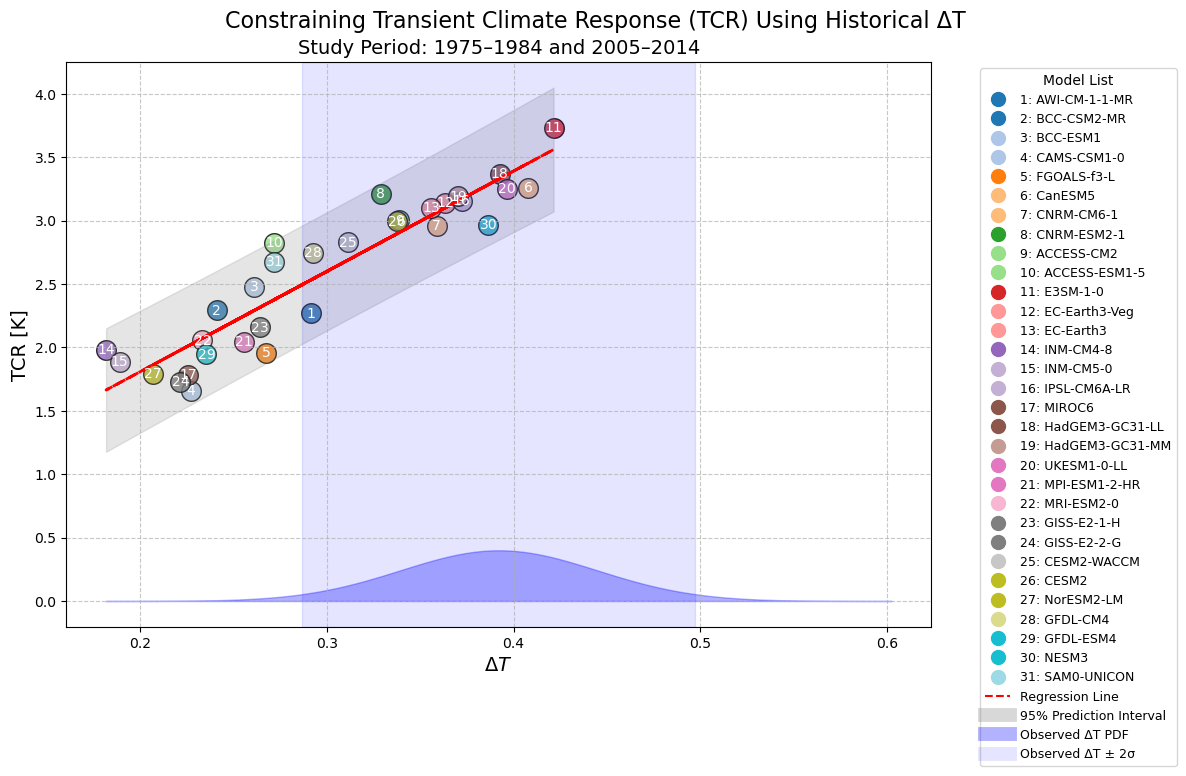

In [8]:
# Extract actual data from your DataFrame
ratios = study_75_14['delta_T']  # ΔT values
tcr_values = study_75_14['TCR']  # TCR values
model_names = study_75_14['Model']  # Model names

# Independent variable (ratios) - Add a constant for intercept
X = sm.add_constant(ratios)
y = tcr_values

# Fit OLS model
model = sm.OLS(y, X).fit()
line_of_best_fit = model.predict(X)

# Prediction intervals only
pred_int = model.get_prediction(X).summary_frame(alpha=0.05)
pred_lower = pred_int['obs_ci_lower']
pred_upper = pred_int['obs_ci_upper']

# Observational ΔT PDF info
obs_mean, obs_std = 0.392, 0.0526
obs_x = np.linspace(obs_mean - 4*obs_std, obs_mean + 4*obs_std, 200)
pdf_x = norm.pdf(obs_x, obs_mean, obs_std)
pdf_x = (pdf_x / pdf_x.max()) * 0.4  # Normalize height for plotting

# Plotting
plt.figure(figsize=(12, 8))
colormap = colormaps.get_cmap('tab20')
colors = [colormap(i / len(model_names)) for i in range(len(model_names))]

# Scatter plot with labels
for i in range(len(ratios)):
    plt.scatter(ratios.iloc[i], tcr_values.iloc[i], s=200, color=colors[i], edgecolor='black', alpha=0.8)
    plt.text(ratios.iloc[i], tcr_values.iloc[i], str(i+1), fontsize=10, ha='center', va='center', color='white')

# Regression line
plt.plot(ratios, line_of_best_fit, color='red', linestyle='--', linewidth=2, label=f'Regression Line\n($R^2={model.rsquared:.2f}$)')

# Prediction interval (keep)
# Sort ratios and corresponding prediction intervals for fill_between
sorted_idx = np.argsort(ratios)
ratios_sorted = ratios.iloc[sorted_idx]
pred_lower_sorted = pred_lower.iloc[sorted_idx]
pred_upper_sorted = pred_upper.iloc[sorted_idx]

plt.fill_between(ratios_sorted, pred_lower_sorted, pred_upper_sorted,
                 color='gray', alpha=0.2, label='95% Prediction Interval')


# Observational ΔT PDF and ±2σ band
plt.fill_between(obs_x, 0, pdf_x, color='blue', alpha=0.3, label='Observed ΔT PDF')
plt.axvspan(obs_mean - 2*obs_std, obs_mean + 2*obs_std, color='blue', alpha=0.1, label='Observed ΔT ± 2σ')

# Legend (models + regression)
handles = [
    plt.Line2D([0], [0], marker='o', color=colors[i], markersize=10, linestyle='None', label=f"{i+1}: {model_names.iloc[i]}")
    for i in range(len(model_names))
]
handles += [
    plt.Line2D([0], [0], color='red', linestyle='--', label='Regression Line'),
    plt.Line2D([0], [0], color='gray', linewidth=10, alpha=0.3, label='95% Prediction Interval'),
    plt.Line2D([0], [0], color='blue', linewidth=10, alpha=0.3, label='Observed ΔT PDF'),
    plt.Line2D([0], [0], color='blue', linewidth=10, alpha=0.1, label='Observed ΔT ± 2σ')
]

plt.legend(handles=handles, title='Model List', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize= '9', fancybox=True)

# Labels and titles
plt.xlabel(r"$\Delta T$", fontsize=14)
plt.ylabel('TCR [K]', fontsize=14)
plt.suptitle('Constraining Transient Climate Response (TCR) Using Historical ΔT', fontsize=16, y=0.9, x= 0.5)
plt.title('Study Period: 1975–1984 and 2005–2014', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust layout to fit suptitle
# plt.subplots_adjust(right=0.75)
plt.savefig('TCR_Regression_with_Obs_Shade_75_14_CMIP6.png', dpi=600)
plt.show()

In [9]:
# --- Observational mean and std dev (ΔT)
obs_mean = 0.392
obs_std  = 0.0526
lower_bound = obs_mean - 2 * obs_std
upper_bound = obs_mean + 2 * obs_std

# --- Load model values
ratios      = study_75_14['delta_T'].values
tcr_values  = study_75_14['TCR'].values
model_names = study_75_14['Model'].values

# --- Filter models within ±2σ range
within_range_mask = (ratios >= lower_bound) & (ratios <= upper_bound)
ratios_within     = ratios[within_range_mask]
tcr_within        = tcr_values[within_range_mask]
models_within     = model_names[within_range_mask]

# --- Report model count
print(f"{len(models_within)} models fall within the very likely observed ΔT range ({lower_bound:.3f}–{upper_bound:.3f} K):")
for name in models_within:
    print(f" - {name}")

# --- Mean and likely range of TCR (±2σ)
mean_tcr_within = np.mean(tcr_within)
std_tcr_within  = np.std(tcr_within, ddof=1)  # sample std dev
lower_tcr = mean_tcr_within - 2 * std_tcr_within
upper_tcr = mean_tcr_within + 2 * std_tcr_within

print(f"\nMean TCR of selected models: {mean_tcr_within:.2f} K")
print(f"Likely range (±2σ) of TCR: {lower_tcr:.2f} K to {upper_tcr:.2f} K")

# --- Regression of TCR vs ΔT (filtered models)
X_within = sm.add_constant(ratios_within)
model_within = sm.OLS(tcr_within, X_within).fit()
slope, intercept = model_within.params
r_squared = model_within.rsquared

print(f"\nRegression line (TCR ≈ a·ΔT + b):")
print(f"  Slope (a)     = {slope:.2f}")
print(f"  Intercept (b) = {intercept:.2f}")
print(f"  R²            = {r_squared:.3f}")

16 models fall within the very likely observed ΔT range (0.287–0.497 K):
 - AWI-CM-1-1-MR
 - CanESM5
 - CNRM-CM6-1
 - CNRM-ESM2-1
 - ACCESS-CM2
 - E3SM-1-0
 - EC-Earth3-Veg
 - EC-Earth3
 - IPSL-CM6A-LR
 - HadGEM3-GC31-LL
 - HadGEM3-GC31-MM
 - UKESM1-0-LL
 - CESM2-WACCM
 - CESM2
 - GFDL-CM4
 - NESM3

Mean TCR of selected models: 3.07 K
Likely range (±2σ) of TCR: 2.44 K to 3.70 K

Regression line (TCR ≈ a·ΔT + b):
  Slope (a)     = 0.68
  Intercept (b) = 6.68
  R²            = 0.692


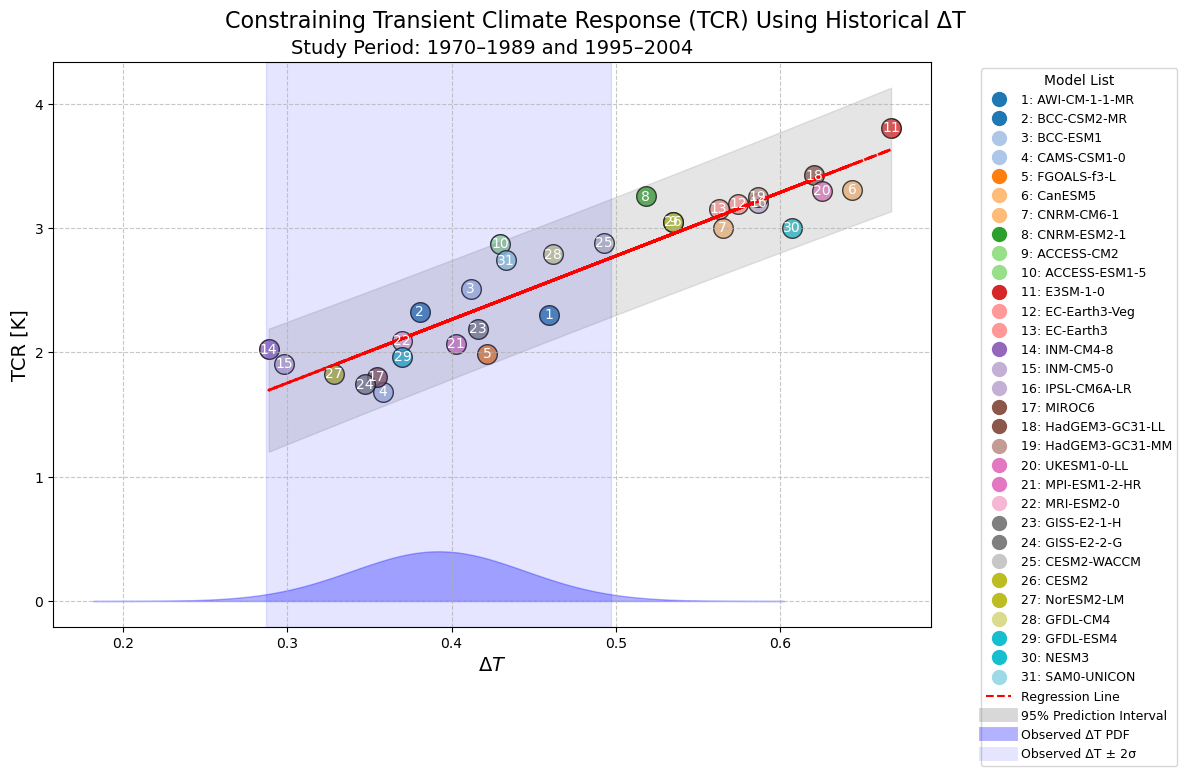

In [10]:
# Extract actual data from your DataFrame
ratios = study_70_04['delta_T']  # ΔT values
tcr_values = study_70_04['TCR']  # TCR values
model_names = study_70_04['Model']  # Model names

# Independent variable (ratios) - Add a constant for intercept
X = sm.add_constant(ratios)
y = tcr_values

# Fit OLS model
model = sm.OLS(y, X).fit()
line_of_best_fit = model.predict(X)

# Prediction intervals only
pred_int = model.get_prediction(X).summary_frame(alpha=0.05)
pred_lower = pred_int['obs_ci_lower']
pred_upper = pred_int['obs_ci_upper']

# Observational ΔT PDF info
obs_mean, obs_std = 0.392, 0.0526
obs_x = np.linspace(obs_mean - 4*obs_std, obs_mean + 4*obs_std, 200)
pdf_x = norm.pdf(obs_x, obs_mean, obs_std)
pdf_x = (pdf_x / pdf_x.max()) * 0.4  # Normalize height for plotting

# Plotting
plt.figure(figsize=(12, 8))
colormap = colormaps.get_cmap('tab20')
colors = [colormap(i / len(model_names)) for i in range(len(model_names))]

# Scatter plot with labels
for i in range(len(ratios)):
    plt.scatter(ratios.iloc[i], tcr_values.iloc[i], s=200, color=colors[i], edgecolor='black', alpha=0.8)
    plt.text(ratios.iloc[i], tcr_values.iloc[i], str(i+1), fontsize=10, ha='center', va='center', color='white')

# Regression line
plt.plot(ratios, line_of_best_fit, color='red', linestyle='--', linewidth=2, label=f'Regression Line\n($R^2={model.rsquared:.2f}$)')

# Prediction interval (keep)
# Sort ratios and corresponding prediction intervals for fill_between
sorted_idx = np.argsort(ratios)
ratios_sorted = ratios.iloc[sorted_idx]
pred_lower_sorted = pred_lower.iloc[sorted_idx]
pred_upper_sorted = pred_upper.iloc[sorted_idx]

plt.fill_between(ratios_sorted, pred_lower_sorted, pred_upper_sorted,
                 color='gray', alpha=0.2, label='95% Prediction Interval')


# Observational ΔT PDF and ±2σ band
plt.fill_between(obs_x, 0, pdf_x, color='blue', alpha=0.3, label='Observed ΔT PDF')
plt.axvspan(obs_mean - 2*obs_std, obs_mean + 2*obs_std, color='blue', alpha=0.1, label='Observed ΔT ± 2σ')

# Legend (models + regression)
handles = [
    plt.Line2D([0], [0], marker='o', color=colors[i], markersize=10, linestyle='None', label=f"{i+1}: {model_names.iloc[i]}")
    for i in range(len(model_names))
]
handles += [
    plt.Line2D([0], [0], color='red', linestyle='--', label='Regression Line'),
    plt.Line2D([0], [0], color='gray', linewidth=10, alpha=0.3, label='95% Prediction Interval'),
    plt.Line2D([0], [0], color='blue', linewidth=10, alpha=0.3, label='Observed ΔT PDF'),
    plt.Line2D([0], [0], color='blue', linewidth=10, alpha=0.1, label='Observed ΔT ± 2σ')
]

plt.legend(handles=handles, title='Model List', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize= '9', fancybox=True)

# Labels and titles
plt.xlabel(r"$\Delta T$", fontsize=14)
plt.ylabel('TCR [K]', fontsize=14)
plt.suptitle('Constraining Transient Climate Response (TCR) Using Historical ΔT', fontsize=16, y=0.9, x= 0.5)
plt.title('Study Period: 1970–1989 and 1995–2004', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust layout to fit suptitle
# plt.subplots_adjust(right=0.75)
plt.savefig('TCR_Regression_with_Obs_Shade_70_04_CMIP6.png', dpi=600)
plt.show()

C:\Users\pbook\AppData\Local\Temp\ipykernel_3740\582645600.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab20', n)


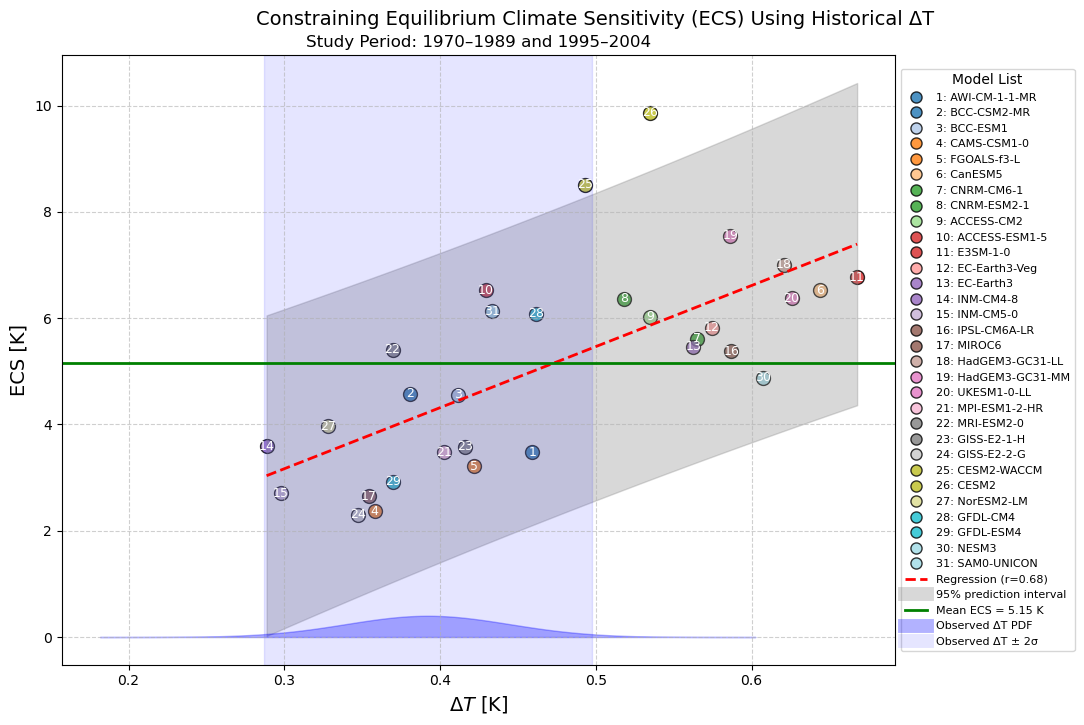

In [11]:
# --- Assumes study_70_04 is preloaded:
ratios      = study_70_04['delta_T'].values
ecs_values  = study_70_04['ECS'].values
model_names = study_70_04['Model'].tolist()
n = len(ratios)

# 1) Fit linear regression: ECS ≈ a·ΔT + b
a, b = np.polyfit(ratios, ecs_values, 1)

# 2) Compute residual scatter σ_r
pred_vals = a * ratios + b
sigma_r   = np.sqrt(np.sum((ecs_values - pred_vals)**2) / (n - 2))

# 3) Prepare regression and prediction interval
x_vals = np.linspace(ratios.min(), ratios.max(), 200)
y_vals = a * x_vals + b

# 4) 95% prediction interval
alpha = 0.05
t_val = t.ppf(1 - alpha/2, df=n-2)
x_bar = ratios.mean()
s_x   = ratios.std(ddof=1)
se_line = sigma_r * np.sqrt(1 + 1/n + ((x_vals - x_bar)**2)/((n - 1)*s_x**2))
pi_lo   = y_vals - t_val * se_line
pi_hi   = y_vals + t_val * se_line

# 5) Mean ECS only (no confidence interval band)
mean_ecs = ecs_values.mean()

# 6) Observational ΔT distribution
obs_mean, obs_std = 0.392, 0.0526
obs_x = np.linspace(obs_mean - 4*obs_std, obs_mean + 4*obs_std, 200)
pdf_x = norm.pdf(obs_x, obs_mean, obs_std)
pdf_x = (pdf_x / pdf_x.max()) * 0.4  # normalize for plotting

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 8))
colormap = plt.cm.get_cmap('tab20', n)
colors   = [colormap(i) for i in range(n)]

# Scatter each model with label
for i, (x, y) in enumerate(zip(ratios, ecs_values), start=1):
    ax.scatter(x, y, color=colors[i-1], edgecolor='k', s=100, alpha=0.8)
    ax.text(x, y, str(i), color='white', ha='center', va='center', fontsize=9)

# Regression line and prediction interval
ax.plot(x_vals, y_vals, 'r--', linewidth=2)
ax.fill_between(x_vals, pi_lo, pi_hi, color='gray', alpha=0.3)

# Horizontal line for mean ECS (no confidence band)
ax.axhline(mean_ecs, color='green', linewidth=2)

# Overlay observational PDF and ±2σ shaded band
ax.fill_between(obs_x, 0, pdf_x, color='blue', alpha=0.3, label='Observed ΔT PDF')
ax.axvspan(obs_mean - 2*obs_std, obs_mean + 2*obs_std, color='blue', alpha=0.1, label='Observed ΔT ± 2σ')

# --- Custom legend ---
handles = [
    Line2D([0], [0], marker='o', color=colors[i], markeredgecolor='k',
           linestyle='None', markersize=8, alpha=0.8, label=f"{i+1}: {model_names[i]}")
    for i in range(n)
]
r_value = np.corrcoef(ratios, ecs_values)[0, 1]
handles += [
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label=f'Regression (r={r_value:.2f})'),
    Line2D([0], [0], color='gray', linewidth=10, alpha=0.3, label='95% prediction interval'),
    Line2D([0], [0], color='green', linewidth=2, label=f'Mean ECS = {mean_ecs:.2f} K'),
    Line2D([0], [0], color='blue', linewidth=10, alpha=0.3, label='Observed ΔT PDF'),
    Line2D([0], [0], color='blue', linewidth=10, alpha=0.1, label='Observed ΔT ± 2σ')
]

ax.legend(handles=handles,
          loc='center left', bbox_to_anchor=(1, 0.5),
          title='Model List', fontsize='8', fancybox=True)

# Labels and title
ax.set_xlabel(r'$\Delta T$ [K]', fontsize=14)
ax.set_ylabel('ECS [K]', fontsize=14)
plt.suptitle('Constraining Equilibrium Climate Sensitivity (ECS) Using Historical ΔT', fontsize=14, y=0.9, x= 0.5)
plt.title('Study Period: 1970–1989 and 1995–2004', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust layout to fit suptitle
plt.subplots_adjust(right=0.75)
plt.savefig("Emerging_Constraint_ECS_wo_CI_70-04.png", dpi=600)
plt.show()

In [12]:
# --- Observational mean and std dev (ΔT)
obs_mean = 0.392
obs_std  = 0.0526
lower_bound = obs_mean - 2 * obs_std
upper_bound = obs_mean + 2 * obs_std

# --- Load model values
ratios      = study_70_04['delta_T'].values
ecs_values  = study_70_04['ECS'].values
model_names = study_70_04['Model'].values

# --- Filter models within ±2σ range
within_range_mask = (ratios >= lower_bound) & (ratios <= upper_bound)
ratios_within     = ratios[within_range_mask]
ecs_within        = ecs_values[within_range_mask]
models_within     = model_names[within_range_mask]

# --- Report model count
print(f"{len(models_within)} models fall within the very likely observed ΔT range ({lower_bound:.3f}–{upper_bound:.3f} K):")
for name in models_within:
    print(f" - {name}")

# --- Mean ECS within the range
mean_ecs_within = np.mean(ecs_within)
std_ecs_within  = np.std(ecs_within, ddof=1)
likely_low  = mean_ecs_within - 2 * std_ecs_within
likely_high = mean_ecs_within + 2 * std_ecs_within

print(f"\nMean ECS of selected models: {mean_ecs_within:.2f} K")
print(f"Likely range (±2σ) of ECS: {likely_low:.2f} K to {likely_high:.2f} K")

# --- Regression of ECS vs ΔT (filtered models)
X_within = sm.add_constant(ratios_within)
model_within = sm.OLS(ecs_within, X_within).fit()
slope, intercept = model_within.params
r_squared = model_within.rsquared

print(f"\nRegression line (ECS ≈ a·ΔT + b):")
print(f"  Slope (a)     = {slope:.2f}")
print(f"  Intercept (b) = {intercept:.2f}")
print(f"  R²            = {r_squared:.3f}")

18 models fall within the very likely observed ΔT range (0.287–0.497 K):
 - AWI-CM-1-1-MR
 - BCC-CSM2-MR
 - BCC-ESM1
 - CAMS-CSM1-0
 - FGOALS-f3-L
 - ACCESS-ESM1-5
 - INM-CM4-8
 - INM-CM5-0
 - MIROC6
 - MPI-ESM1-2-HR
 - MRI-ESM2-0
 - GISS-E2-1-H
 - GISS-E2-2-G
 - CESM2-WACCM
 - NorESM2-LM
 - GFDL-CM4
 - GFDL-ESM4
 - SAM0-UNICON

Mean ECS of selected models: 4.22 K
Likely range (±2σ) of ECS: 0.83 K to 7.62 K

Regression line (ECS ≈ a·ΔT + b):
  Slope (a)     = -3.45
  Intercept (b) = 19.68
  R²            = 0.426


C:\Users\pbook\AppData\Local\Temp\ipykernel_3740\809110927.py:38: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colormap = plt.cm.get_cmap('tab20', n)


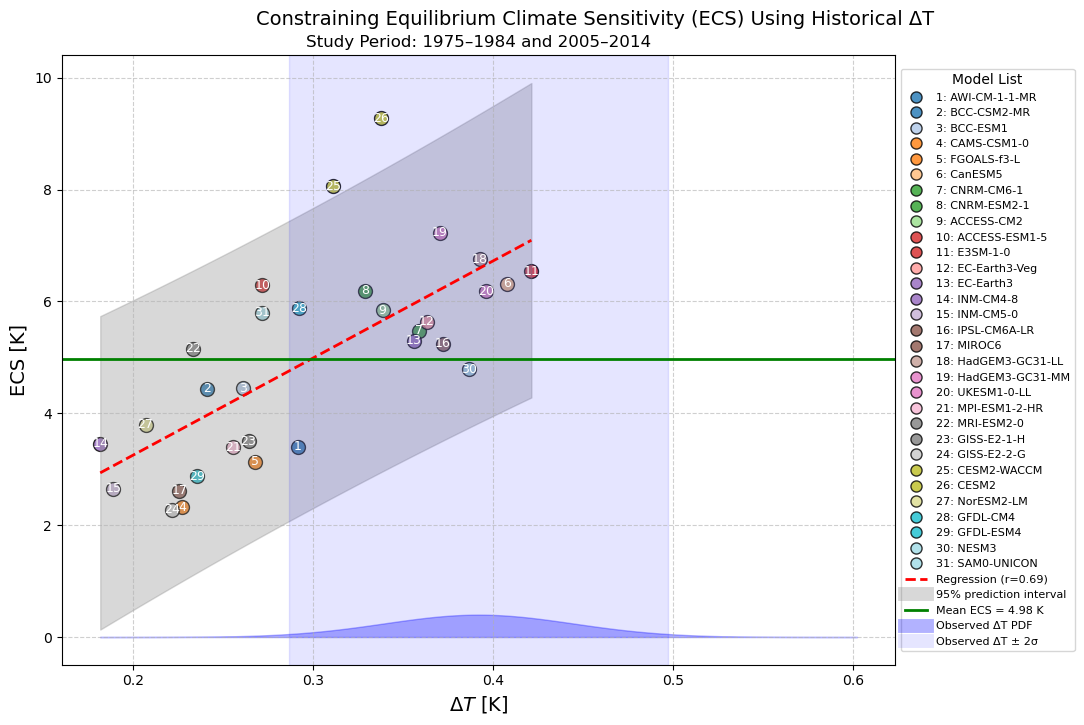

In [13]:
# --- Assumes study_75_14 is preloaded:
ratios      = study_75_14['delta_T'].values
ecs_values  = study_75_14['ECS'].values
model_names = study_75_14['Model'].tolist()
n = len(ratios)

# 1) Fit linear regression: ECS ≈ a·ΔT + b
a, b = np.polyfit(ratios, ecs_values, 1)

# 2) Compute residual scatter σ_r
pred_vals = a * ratios + b
sigma_r   = np.sqrt(np.sum((ecs_values - pred_vals)**2) / (n - 2))

# 3) Prepare regression and prediction interval
x_vals = np.linspace(ratios.min(), ratios.max(), 200)
y_vals = a * x_vals + b

# 4) 95% prediction interval
alpha = 0.05
t_val = t.ppf(1 - alpha/2, df=n-2)
x_bar = ratios.mean()
s_x   = ratios.std(ddof=1)
se_line = sigma_r * np.sqrt(1 + 1/n + ((x_vals - x_bar)**2)/((n - 1)*s_x**2))
pi_lo   = y_vals - t_val * se_line
pi_hi   = y_vals + t_val * se_line

# 5) Mean ECS only (no confidence interval band)
mean_ecs = ecs_values.mean()

# 6) Observational ΔT distribution
obs_mean, obs_std = 0.392, 0.0526
obs_x = np.linspace(obs_mean - 4*obs_std, obs_mean + 4*obs_std, 200)
pdf_x = norm.pdf(obs_x, obs_mean, obs_std)
pdf_x = (pdf_x / pdf_x.max()) * 0.4  # normalize for plotting

# --- Plotting ---
fig, ax = plt.subplots(figsize=(12, 8))
colormap = plt.cm.get_cmap('tab20', n)
colors   = [colormap(i) for i in range(n)]

# Scatter each model with label
for i, (x, y) in enumerate(zip(ratios, ecs_values), start=1):
    ax.scatter(x, y, color=colors[i-1], edgecolor='k', s=100, alpha=0.8)
    ax.text(x, y, str(i), color='white', ha='center', va='center', fontsize=9)

# Regression line and prediction interval
ax.plot(x_vals, y_vals, 'r--', linewidth=2)
ax.fill_between(x_vals, pi_lo, pi_hi, color='gray', alpha=0.3)

# Horizontal line for mean ECS (no confidence band)
ax.axhline(mean_ecs, color='green', linewidth=2)

# Overlay observational PDF and ±2σ shaded band
ax.fill_between(obs_x, 0, pdf_x, color='blue', alpha=0.3, label='Observed ΔT PDF')
ax.axvspan(obs_mean - 2*obs_std, obs_mean + 2*obs_std, color='blue', alpha=0.1, label='Observed ΔT ± 2σ')

# --- Custom legend ---
handles = [
    Line2D([0], [0], marker='o', color=colors[i], markeredgecolor='k',
           linestyle='None', markersize=8, alpha=0.8, label=f"{i+1}: {model_names[i]}")
    for i in range(n)
]
r_value = np.corrcoef(ratios, ecs_values)[0, 1]
handles += [
    Line2D([0], [0], color='red', linestyle='--', linewidth=2, label=f'Regression (r={r_value:.2f})'),
    Line2D([0], [0], color='gray', linewidth=10, alpha=0.3, label='95% prediction interval'),
    Line2D([0], [0], color='green', linewidth=2, label=f'Mean ECS = {mean_ecs:.2f} K'),
    Line2D([0], [0], color='blue', linewidth=10, alpha=0.3, label='Observed ΔT PDF'),
    Line2D([0], [0], color='blue', linewidth=10, alpha=0.1, label='Observed ΔT ± 2σ')
]

ax.legend(handles=handles,
          loc='center left', bbox_to_anchor=(1, 0.5),
          title='Model List', fontsize='8', fancybox=True)

# Labels and title
ax.set_xlabel(r'$\Delta T$ [K]', fontsize=14)
ax.set_ylabel('ECS [K]', fontsize=14)
plt.suptitle('Constraining Equilibrium Climate Sensitivity (ECS) Using Historical ΔT', fontsize=14, y=0.9, x= 0.5)
plt.title('Study Period: 1975–1984 and 2005–2014', fontsize=12)
ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.93])  # Adjust layout to fit suptitle
plt.subplots_adjust(right=0.75)
plt.savefig("Emerging_Constraint_ECS_wo_CI_75-14.png", dpi=600)
plt.show()